# Notebook 4 - Detailed EDA on the Training Split Only

## Guardrail

This notebook opens only `03_train.parquet`. Validation and test artifacts are not read. The goal is to make feature and modeling decisions without allowing the test set to influence them.

In [1]:
from pathlib import Path
import json
import warnings
warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
ARTIFACTS = ROOT / "artifacts"
FIGURES = ROOT / "figures"
REPORTS = ROOT / "reports"
for folder in [ARTIFACTS, FIGURES, REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)
print(f"Task root: {ROOT.resolve()}")

Task root: C:\Users\moath\Desktop\MLOPS\MLOps_Task1_Rand_Salem\MLOps-Qafza-2026\Tasks\Task-02


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
source = ARTIFACTS / "03_train.parquet"
assert source.exists(), "Run Notebook 3 first."
train = pd.read_parquet(source)
for column in train.columns:
    if "date" in column or "timestamp" in column:
        train[column] = pd.to_datetime(train[column], errors="coerce")
print("Training shape:", train.shape)
print("Memory MB:", round(train.memory_usage(deep=True).sum() / 1024**2, 2))

Training shape: (67529, 39)
Memory MB: 57.14


## 1. Data types and missing values

In [3]:
type_summary = pd.DataFrame({
    "dtype": train.dtypes.astype(str),
    "non_null": train.notna().sum(),
    "missing": train.isna().sum(),
    "missing_pct": 100 * train.isna().mean(),
    "unique": train.nunique(dropna=True),
}).sort_values(["missing_pct", "unique"], ascending=[False, False])
type_summary.to_csv(REPORTS / "04_column_quality.csv")
type_summary.head(20)

,dtype,non_null,missing,missing_pct,unique
primary_category,object,66328,1201,1.778495,71
product_photos_mean,float64,66332,1197,1.772572,58
customer_seller_distance_km,float64,67185,344,0.509411,63763
customer_lat,float64,67348,181,0.268033,13627
customer_lng,float64,67348,181,0.268033,13626
seller_lat_mean,float64,67365,164,0.242859,2344
seller_lng_mean,float64,67365,164,0.242859,2334
product_weight_mean,float64,67513,16,0.023694,2272
product_length_mean,float64,67513,16,0.023694,268
product_height_mean,float64,67513,16,0.023694,263


## 2. Numerical statistics, skew, and suspicious ranges

In [4]:
excluded_post_delivery = {
    "is_late", "delivery_delay_days", "order_delivered_customer_date",
    "order_delivered_carrier_date", "order_approved_at",
}
numeric_columns = [
    c for c in train.select_dtypes(include=np.number).columns
    if c not in excluded_post_delivery and not c.endswith("zip_code_prefix")
]
numerical_summary = train[numeric_columns].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T
numerical_summary["skew"] = train[numeric_columns].skew(numeric_only=True)
numerical_summary.to_csv(REPORTS / "04_numerical_summary.csv")
numerical_summary.sort_values("skew", key=lambda s: s.abs(), ascending=False).head(15)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
payment_count,67528.0,1.047625,0.397223,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000,26.000000,22.419509
seller_state_nunique,67529.0,1.004679,0.069323,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,3.000000,15.177527
price_total,67529.0,135.888797,205.194019,2.290000,11.990000,19.000000,45.900000,85.000000,149.90000,399.000000,987.000000,13440.000000,10.718895
seller_count,67529.0,1.012054,0.114815,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000,5.000000,10.524938
payment_value_total,67528.0,158.173637,214.285757,10.070000,22.950000,32.380000,61.630000,104.190000,175.50000,439.394500,1039.856800,13664.080000,10.149318
freight_total,67529.0,22.245936,20.002594,0.000000,7.780000,8.370000,14.100000,16.790000,23.70000,51.846000,98.171600,1002.290000,8.581743
item_count,67529.0,1.142072,0.541640,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,2.000000,3.000000,21.000000,8.107162
price_mean,67529.0,124.239070,185.659661,1.514286,10.990000,18.500000,41.000000,78.970000,139.90000,359.000000,899.000000,6735.000000,7.802465
product_count,67529.0,1.037702,0.222199,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000,7.000000,7.677312
payment_type_count,67528.0,1.024020,0.153111,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,2.000000,2.000000,6.217627


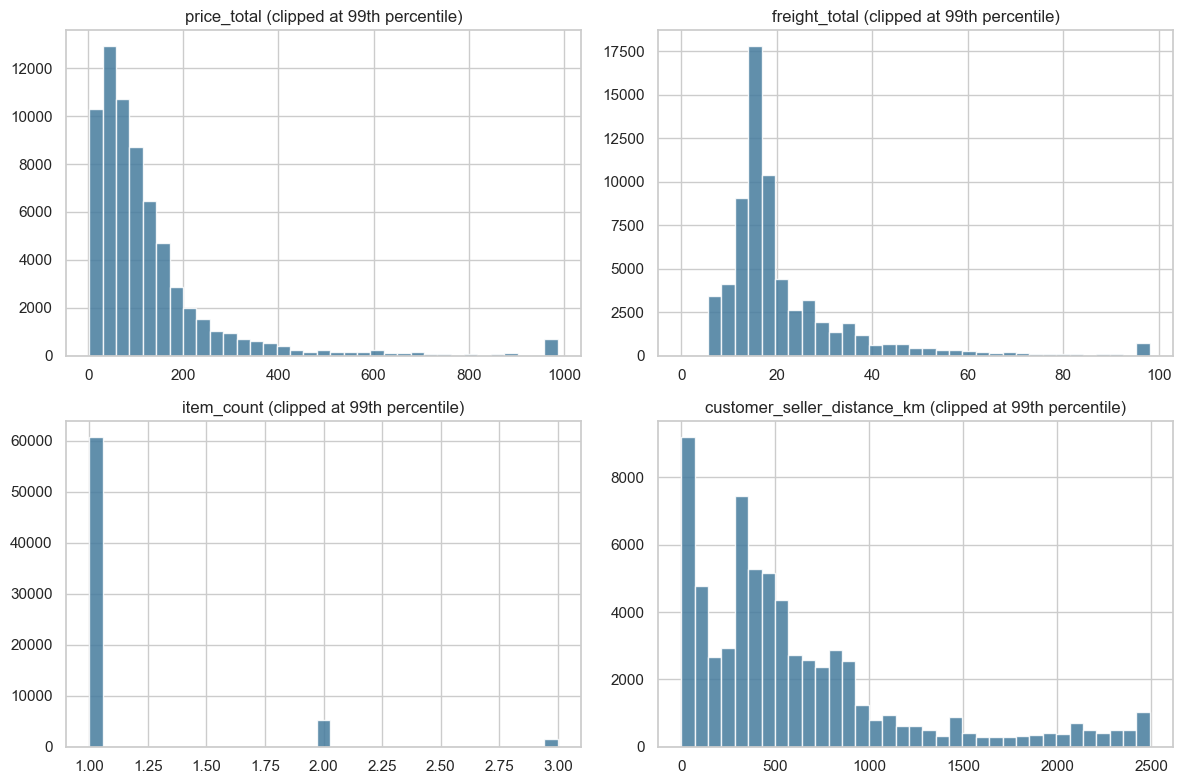

In [5]:
plot_columns = [c for c in ["price_total", "freight_total", "item_count", "customer_seller_distance_km"] if c in train]
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, column in zip(axes.flat, plot_columns):
    clipped = train[column].clip(upper=train[column].quantile(.99))
    ax.hist(clipped.dropna(), bins=35, color="#457B9D", alpha=.85)
    ax.set_title(f"{column} (clipped at 99th percentile)")
for ax in axes.flat[len(plot_columns):]:
    ax.axis("off")
fig.tight_layout()
fig.savefig(FIGURES / "04_numerical_distributions.png", dpi=180, bbox_inches="tight")
plt.show()

## 3. Categorical cardinality and rare values

In [6]:
categorical_columns = [
    c for c in ["customer_state", "primary_seller_state", "primary_category", "dominant_payment_type"]
    if c in train
]
categorical_summary = pd.DataFrame([
    {
        "column": column,
        "cardinality": train[column].nunique(dropna=True),
        "missing_pct": 100 * train[column].isna().mean(),
        "rare_values_under_20_rows": int((train[column].value_counts() < 20).sum()),
        "most_common": train[column].mode().iloc[0] if train[column].notna().any() else None,
    }
    for column in categorical_columns
])
categorical_summary.to_csv(REPORTS / "04_categorical_summary.csv", index=False)
categorical_summary

,column,cardinality,missing_pct,rare_values_under_20_rows,most_common
0,customer_state,27,0.000000,0,SP
1,primary_seller_state,22,0.000000,5,SP
2,primary_category,71,1.778495,8,bed_bath_table
3,dominant_payment_type,4,0.001481,0,credit_card


## 4. Relationships with the label

In [7]:
label_rates = {}
for column in [c for c in ["customer_state", "dominant_payment_type", "primary_seller_state"] if c in train]:
    rates = (
        train.groupby(column, dropna=False)["is_late"]
        .agg(["mean", "count"])
        .query("count >= 100")
        .sort_values("mean", ascending=False)
    )
    label_rates[column] = rates
    print(f"\nLate rate by {column} (minimum 100 orders):")
    display(rates.head(10))


Late rate by customer_state (minimum 100 orders):


,mean,count
customer_state,,
AL,0.278523,298
MA,0.215328,548
CE,0.182489,948
SE,0.170732,246
PI,0.166667,348
RJ,0.165867,8965
BA,0.149978,2307
PA,0.133705,718
ES,0.132872,1445



Late rate by dominant_payment_type (minimum 100 orders):


,mean,count
dominant_payment_type,,
debit_card,0.098854,698
boleto,0.094094,13901
credit_card,0.089435,51557
voucher,0.077988,1372



Late rate by primary_seller_state (minimum 100 orders):


,mean,count
primary_seller_state,,
RJ,0.098446,2702
SP,0.098154,47772
PR,0.076509,5385
ES,0.075099,253
SC,0.065276,2589
BA,0.063570,409
DF,0.063032,587
MG,0.061981,5663
PE,0.061611,211


In [8]:
available_numeric = train[numeric_columns + ["is_late"]].copy()
correlations = available_numeric.corr(numeric_only=True)["is_late"].drop("is_late").sort_values(key=abs, ascending=False)
correlations.to_csv(REPORTS / "04_feature_label_correlations.csv", header=["correlation"])
correlations.head(15)

customer_seller_distance_km    0.086517
customer_lng                   0.082651
freight_mean                   0.069311
customer_lat                   0.061400
freight_total                  0.046597
price_mean                     0.027407
seller_count                  -0.025871
product_weight_mean            0.025670
payment_value_total            0.024776
seller_lat_mean                0.023924
product_count                 -0.021589
price_total                    0.021336
product_length_mean            0.020134
seller_state_nunique          -0.018282
payment_installments_max       0.017183
Name: is_late, dtype: float64

## 5. Dates and seasonality

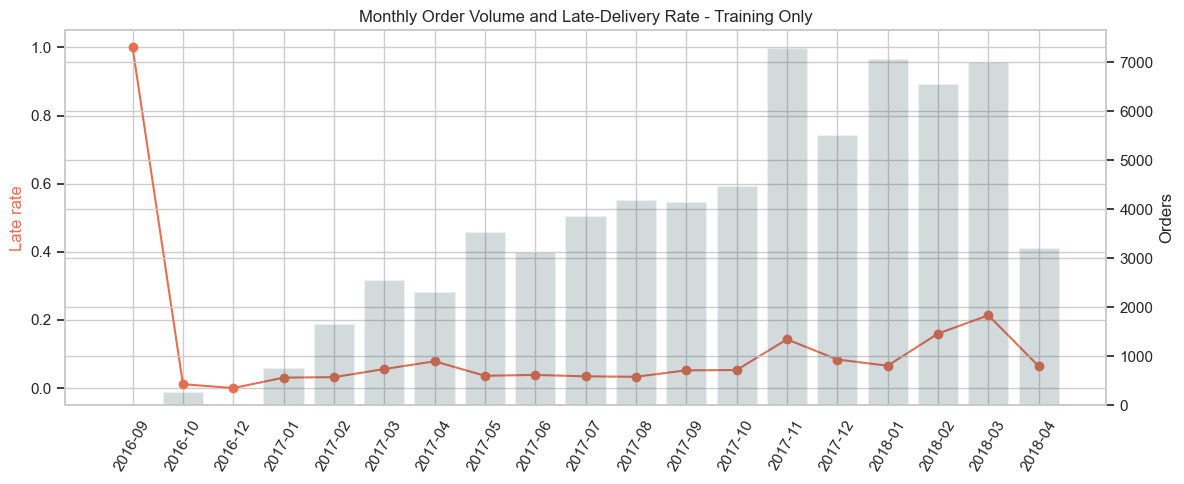

In [9]:
train["purchase_month"] = train["order_purchase_timestamp"].dt.to_period("M").astype(str)
monthly = train.groupby("purchase_month")["is_late"].agg(["mean", "count"]).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly["purchase_month"], monthly["mean"], marker="o", color="#E76F51")
ax1.set_ylabel("Late rate", color="#E76F51")
ax1.tick_params(axis="x", rotation=60)
ax2 = ax1.twinx()
ax2.bar(monthly["purchase_month"], monthly["count"], alpha=.2, color="#264653")
ax2.set_ylabel("Orders")
ax1.set_title("Monthly Order Volume and Late-Delivery Rate - Training Only")
fig.tight_layout()
fig.savefig(FIGURES / "04_monthly_late_rate.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Geography

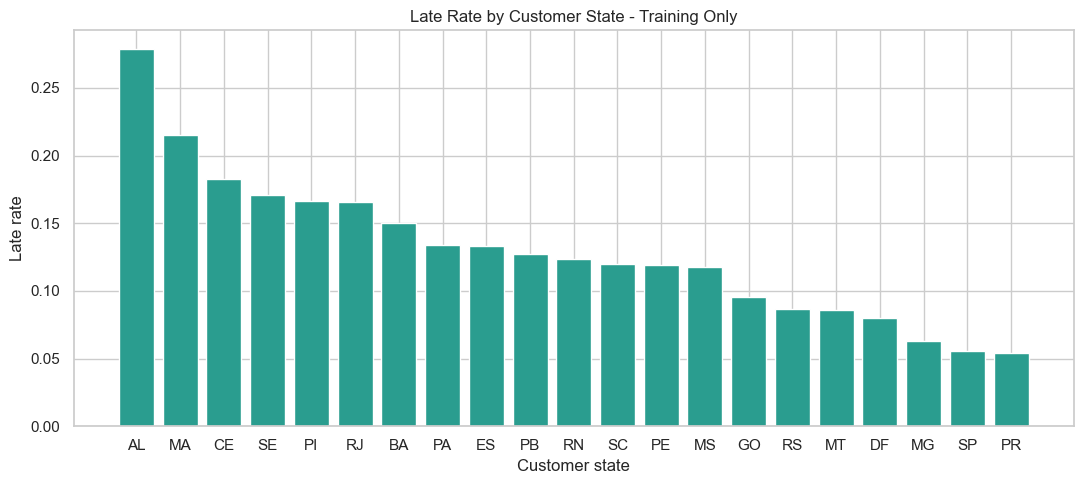

,late_rate,orders
customer_state,,
AL,0.278523,298
MA,0.215328,548
CE,0.182489,948
SE,0.170732,246
PI,0.166667,348
RJ,0.165867,8965
BA,0.149978,2307
PA,0.133705,718
ES,0.132872,1445


In [10]:
state_rates = (
    train.groupby("customer_state")["is_late"]
    .agg(late_rate="mean", orders="count")
    .query("orders >= 200")
    .sort_values("late_rate", ascending=False)
)
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(state_rates.index, state_rates["late_rate"], color="#2A9D8F")
ax.set(title="Late Rate by Customer State - Training Only", ylabel="Late rate", xlabel="Customer state")
fig.tight_layout()
fig.savefig(FIGURES / "04_customer_state_late_rate.png", dpi=180, bbox_inches="tight")
plt.show()
state_rates

## 7. Save findings summary

In [11]:
late_rate = train["is_late"].mean()
top_corr = correlations.index[0] if len(correlations) else "none"
top_state = state_rates.index[0] if len(state_rates) else "none"
findings = f"""# Task 2 EDA Findings - Training Split Only

- Training rows: {len(train):,}; columns: {train.shape[1]}.
- Late-delivery prevalence: {late_rate:.2%}, confirming a materially imbalanced target.
- The strongest univariate numerical association with the label was `{top_corr}`; this is descriptive, not causal.
- Among states with at least 200 training orders, `{top_state}` had the highest observed late rate.
- Price, freight, item-count, and distance features are skewed; robust imputation and scaling are appropriate.
- Rare product categories require an encoder that safely handles infrequent and unseen values.
- Monthly late rates vary, so purchase month and day-of-week are retained as prediction-time features.
- Post-delivery timestamps, reviews, delivery delay, and order status are excluded from modeling to prevent leakage.
"""
(REPORTS / "04_eda_findings.md").write_text(findings, encoding="utf-8")
print(findings)

# Task 2 EDA Findings - Training Split Only

- Training rows: 67,529; columns: 40.
- Late-delivery prevalence: 9.03%, confirming a materially imbalanced target.
- The strongest univariate numerical association with the label was `customer_seller_distance_km`; this is descriptive, not causal.
- Among states with at least 200 training orders, `AL` had the highest observed late rate.
- Price, freight, item-count, and distance features are skewed; robust imputation and scaling are appropriate.
- Rare product categories require an encoder that safely handles infrequent and unseen values.
- Monthly late rates vary, so purchase month and day-of-week are retained as prediction-time features.
- Post-delivery timestamps, reviews, delivery delay, and order status are excluded from modeling to prevent leakage.

